### Importações

In [57]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score, average_precision_score, make_scorer, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

### Treinamento do primeiro modelo

In [58]:
df1 = pd.read_csv('dados/dados_modelo1.csv')

df1.info()

df1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1375 entries, 0 to 1374
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Idade_Maior  1375 non-null   float64
 1   STEM_SI      1375 non-null   float64
 2   Quiz1        1375 non-null   float64
 3   Quiz2        1375 non-null   float64
 4   Quiz3        1375 non-null   float64
 5   TempoQ1      1375 non-null   float64
 6   TempoQ2      1375 non-null   float64
 7   TempoQ3      1374 non-null   float64
 8   Reprovou     1375 non-null   int64  
dtypes: float64(8), int64(1)
memory usage: 96.8 KB


,Idade_Maior,STEM_SI,Quiz1,Quiz2,Quiz3,TempoQ1,TempoQ2,TempoQ3,Reprovou
0,1.0,0.0,1.0,0.000000,0.0,0.426877,1.000000,1.000000,1
1,1.0,0.0,1.0,1.000000,0.6,0.553360,0.612613,0.534026,0
2,1.0,1.0,0.0,0.000000,0.2,1.000000,1.000000,0.114286,1
3,1.0,0.0,0.6,0.000000,0.6,0.316206,1.000000,0.280519,0
4,0.0,1.0,1.0,0.679487,0.6,0.318841,0.276276,0.132987,1


In [59]:
linhas_com_nan = df1[df1.isna().any(axis=1)]

linhas_com_nan

df1 = df1.fillna(0.09375)

df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1375 entries, 0 to 1374
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Idade_Maior  1375 non-null   float64
 1   STEM_SI      1375 non-null   float64
 2   Quiz1        1375 non-null   float64
 3   Quiz2        1375 non-null   float64
 4   Quiz3        1375 non-null   float64
 5   TempoQ1      1375 non-null   float64
 6   TempoQ2      1375 non-null   float64
 7   TempoQ3      1375 non-null   float64
 8   Reprovou     1375 non-null   int64  
dtypes: float64(8), int64(1)
memory usage: 96.8 KB


In [60]:
X = df1.drop('Reprovou', axis=1)

y = df1['Reprovou'].replace({0: 1, 1: 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC())
])

In [61]:
param_grid = {
    "svm__kernel": ["linear", "rbf"],
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale", 0.01, 0.1, 1]
}

grid = GridSearchCV(pipeline, param_grid, scoring="f1_macro", cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print("Melhores parâmetros:", grid.best_params_)
print("Média CV (f1_macro):", grid.best_score_)
print("Score no teste:", grid.score(X_test, y_test))

y_pred = grid.predict(X_test)
print("\nRelatório de classificação:\n", classification_report(y_test, y_pred))

Melhores parâmetros: {'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Média CV (f1_macro): 0.6032965139161813
Score no teste: 0.5490350431691214

Relatório de classificação:
               precision    recall  f1-score   support

           0       0.14      0.50      0.22        24
           1       0.96      0.81      0.88       389

    accuracy                           0.79       413
   macro avg       0.55      0.65      0.55       413
weighted avg       0.92      0.79      0.84       413



### Treinamento do segundo modelo

In [62]:
df2 = pd.read_csv('dados/dados_modelo2.csv')

df2.info()

df2.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1375 entries, 0 to 1374
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Idade_Maior  1375 non-null   float64
 1   STEM_SI      1375 non-null   float64
 2   Quiz1        1375 non-null   float64
 3   Quiz2        1375 non-null   float64
 4   Quiz3        1375 non-null   float64
 5   Quiz4        1375 non-null   float64
 6   TempoQ1      1375 non-null   float64
 7   TempoQ2      1375 non-null   float64
 8   TempoQ3      1374 non-null   float64
 9   TempoQ4      1375 non-null   float64
 10  Parcial_1    1375 non-null   float64
 11  Reprovou     1375 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 129.0 KB


,Idade_Maior,STEM_SI,Quiz1,Quiz2,Quiz3,Quiz4,TempoQ1,TempoQ2,TempoQ3,TempoQ4,Parcial_1,Reprovou
0,1.0,0.0,1.0,0.000000,0.0,0.5,0.426877,1.000000,1.000000,0.452759,0.628571,1
1,1.0,0.0,1.0,1.000000,0.6,0.0,0.553360,0.612613,0.534026,1.000000,0.500000,0
2,1.0,1.0,0.0,0.000000,0.2,0.0,1.000000,1.000000,0.114286,1.000000,0.000000,1
3,1.0,0.0,0.6,0.000000,0.6,0.5,0.316206,1.000000,0.280519,0.212171,0.228571,0
4,0.0,1.0,1.0,0.679487,0.6,0.5,0.318841,0.276276,0.132987,0.318257,0.000000,1


In [63]:
linhas_com_nan = df2[df2.isna().any(axis=1)]

linhas_com_nan

df2 = df2.fillna(0.09375)

df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1375 entries, 0 to 1374
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Idade_Maior  1375 non-null   float64
 1   STEM_SI      1375 non-null   float64
 2   Quiz1        1375 non-null   float64
 3   Quiz2        1375 non-null   float64
 4   Quiz3        1375 non-null   float64
 5   Quiz4        1375 non-null   float64
 6   TempoQ1      1375 non-null   float64
 7   TempoQ2      1375 non-null   float64
 8   TempoQ3      1375 non-null   float64
 9   TempoQ4      1375 non-null   float64
 10  Parcial_1    1375 non-null   float64
 11  Reprovou     1375 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 129.0 KB


In [64]:
X2 = df2.drop('Reprovou', axis=1)

y2 = df2['Reprovou'].replace({0: 1, 1: 0})

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.3, random_state=42, stratify=y
)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC())
])

In [65]:
param_grid = {
    "svm__kernel": ["linear", "rbf"],
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale", 0.01, 0.1, 1]
}

grid = GridSearchCV(pipeline, param_grid, scoring="f1_macro", cv=5, n_jobs=-1)
grid.fit(X2_train, y2_train)

print("Melhores parâmetros:", grid.best_params_)
print("Média CV (f1_macro):", grid.best_score_)
print("Score no teste:", grid.score(X2_test, y2_test))

y2_pred = grid.predict(X2_test)
print("\nRelatório de classificação:\n", classification_report(y2_test, y2_pred))

Melhores parâmetros: {'svm__C': 10, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Média CV (f1_macro): 0.6702863180910048
Score no teste: 0.5874714611872146

Relatório de classificação:
               precision    recall  f1-score   support

           0       0.18      0.54      0.27        24
           1       0.97      0.85      0.90       389

    accuracy                           0.83       413
   macro avg       0.57      0.69      0.59       413
weighted avg       0.92      0.83      0.87       413



### Treinamento do terceiro modelo

In [66]:
df3 = pd.read_csv('dados/dados_modelo3.csv')

df3.info()

df3.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1375 entries, 0 to 1374
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Idade_Maior  1375 non-null   float64
 1   STEM_SI      1375 non-null   float64
 2   Quiz1        1375 non-null   float64
 3   Quiz2        1375 non-null   float64
 4   Quiz3        1375 non-null   float64
 5   Quiz4        1375 non-null   float64
 6   Quiz5        1375 non-null   float64
 7   Quiz6        1375 non-null   float64
 8   TempoQ1      1375 non-null   float64
 9   TempoQ2      1375 non-null   float64
 10  TempoQ3      1374 non-null   float64
 11  TempoQ4      1375 non-null   float64
 12  TempoQ5      1375 non-null   float64
 13  TempoQ6      1375 non-null   float64
 14  Parcial_1    1375 non-null   float64
 15  Reprovou     1375 non-null   int64  
dtypes: float64(15), int64(1)
memory usage: 172.0 KB


,Idade_Maior,STEM_SI,Quiz1,Quiz2,Quiz3,Quiz4,Quiz5,Quiz6,TempoQ1,TempoQ2,TempoQ3,TempoQ4,TempoQ5,TempoQ6,Parcial_1,Reprovou
0,1.0,0.0,1.0,0.000000,0.0,0.5,0.0,0.00,0.426877,1.000000,1.000000,0.452759,1.0,1.000000,0.628571,1
1,1.0,0.0,1.0,1.000000,0.6,0.0,0.0,0.20,0.553360,0.612613,0.534026,1.000000,1.0,0.181985,0.500000,0
2,1.0,1.0,0.0,0.000000,0.2,0.0,0.0,0.28,1.000000,1.000000,0.114286,1.000000,1.0,0.130515,0.000000,1
3,1.0,0.0,0.6,0.000000,0.6,0.5,0.0,1.00,0.316206,1.000000,0.280519,0.212171,1.0,0.562500,0.228571,0
4,0.0,1.0,1.0,0.679487,0.6,0.5,0.0,0.00,0.318841,0.276276,0.132987,0.318257,1.0,1.000000,0.000000,1


In [67]:
linhas_com_nan = df3[df3.isna().any(axis=1)]

linhas_com_nan

df3 = df3.fillna(0.09375)

df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1375 entries, 0 to 1374
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Idade_Maior  1375 non-null   float64
 1   STEM_SI      1375 non-null   float64
 2   Quiz1        1375 non-null   float64
 3   Quiz2        1375 non-null   float64
 4   Quiz3        1375 non-null   float64
 5   Quiz4        1375 non-null   float64
 6   Quiz5        1375 non-null   float64
 7   Quiz6        1375 non-null   float64
 8   TempoQ1      1375 non-null   float64
 9   TempoQ2      1375 non-null   float64
 10  TempoQ3      1375 non-null   float64
 11  TempoQ4      1375 non-null   float64
 12  TempoQ5      1375 non-null   float64
 13  TempoQ6      1375 non-null   float64
 14  Parcial_1    1375 non-null   float64
 15  Reprovou     1375 non-null   int64  
dtypes: float64(15), int64(1)
memory usage: 172.0 KB


In [68]:
X3 = df3.drop('Reprovou', axis=1)

y3 = df3['Reprovou'].replace({0: 1, 1: 0})

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.3, random_state=42, stratify=y
)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC())
])

In [69]:
param_grid = {
    "svm__kernel": ["linear", "rbf"],
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale", 0.01, 0.1, 1]
}

grid = GridSearchCV(pipeline, param_grid, scoring="f1_macro", cv=5, n_jobs=-1)
grid.fit(X3_train, y3_train)

print("Melhores parâmetros:", grid.best_params_)
print("Média CV (f1_macro):", grid.best_score_)
print("Score no teste:", grid.score(X3_test, y3_test))

y3_pred = grid.predict(X3_test)
print("\nRelatório de classificação:\n", classification_report(y3_test, y3_pred))

Melhores parâmetros: {'svm__C': 1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Média CV (f1_macro): 0.6969773437263429
Score no teste: 0.6420756147762973

Relatório de classificação:
               precision    recall  f1-score   support

           0       0.24      0.79      0.37        24
           1       0.99      0.85      0.91       389

    accuracy                           0.85       413
   macro avg       0.61      0.82      0.64       413
weighted avg       0.94      0.85      0.88       413



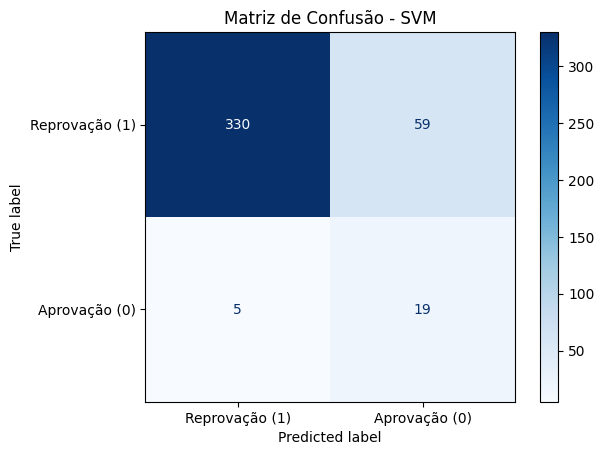

In [70]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(
    y3_test,
    y3_pred,
    display_labels=["Reprovação (1)", "Aprovação (0)"],  
    cmap="Blues",
    values_format="d",
    labels=[1, 0]
)
plt.title("Matriz de Confusão - SVM")
plt.show()